# Denoising autoencoder

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.optim import Adam
import matplotlib.pyplot as plt
import random
import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = 'mps'  # solo para MacOS!

## Datos de entrenamiento

In [2]:
dataset = datasets.FashionMNIST('data', transform=transforms.ToTensor(), download=True)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

100%|██████████| 26.4M/26.4M [00:05<00:00, 4.57MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 103kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.26MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 532kB/s]


## Red neuronal

In [3]:
class Autoencoder(nn.Module):

    def __init__(self, img_shape):
        super().__init__()

        self.img_shape = img_shape
        n_features = img_shape[0] * img_shape[1] * img_shape[2]

        self.autoencoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, n_features), nn.Sigmoid(),
            nn.Unflatten(1, img_shape)
        )

    def forward(self, x):
        return self.autoencoder(x)

## Entrenamiento

In [4]:
def train_dae(autoencoder, dataloader, optimizer, epochs, p_range):

    autoencoder.to(DEVICE)

    try:
        loss_fn = nn.MSELoss()

        progressbar = tqdm.trange(epochs)
        for epoch in progressbar:

            for x, _ in dataloader:
                x = x.to(DEVICE)

                # Inyección de ruido:
                p = random.uniform(*p_range)
                B, C, H, W = x.size()
                noise = torch.empty([B, 1, H, W], device=DEVICE).bernoulli_(p)
                noisy_x = x * (1 - noise)

                # Denoising:
                output = autoencoder(noisy_x)

                # Entrenamiento:
                loss = loss_fn(output, x)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

    except KeyboardInterrupt:
        print('Entrenamiento interrumpido.')

In [5]:
img_shape = dataset[0][0].shape
autoencoder = Autoencoder(img_shape)

optimizer = Adam(autoencoder.parameters())
train_dae(autoencoder, dataloader, optimizer, epochs=5, p_range=[0.3, 0.7])

100%|██████████| 5/5 [00:29<00:00,  5.90s/it]


## Evaluación

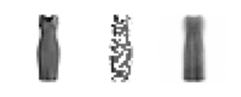

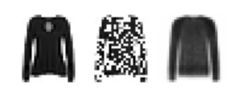

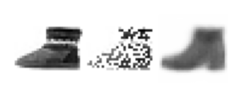

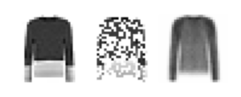

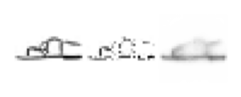

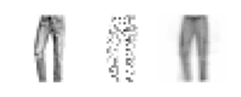

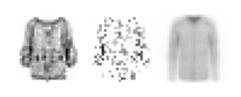

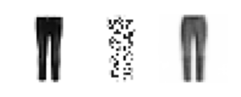

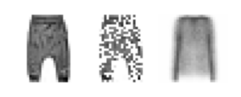

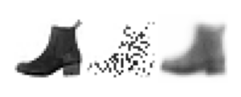

In [6]:
autoencoder.eval()
autoencoder.cpu()

for _ in range(10):

    # Imagen real:
    idx = random.randint(0, len(dataset))
    true_img, _ = dataset[idx]

    # Imagen ruidosa:
    p = random.uniform(0.3, 0.7)
    noise = torch.empty(true_img.size()[1:]).bernoulli_(p)
    noisy_img = true_img * (1 - noise)

    # Imagen reconstruida:
    output = autoencoder(noisy_img.unsqueeze(0))
    reconstructed_img = output[0].detach().cpu()

    img_grid = make_grid([true_img, noisy_img, reconstructed_img])
    plt.figure(figsize=(3, 1))
    plt.imshow(1 - img_grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()